In [54]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [55]:
dataset = pd.read_csv("Synthetic Fraud Detection Data.csv")
dataset.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [56]:
import pandas as pd

# 1. Load dataset (THIS WAS MISSING)
df = pd.read_csv("Synthetic Fraud Detection Data.csv")

# 2. Select columns
data = df[["oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest", "amount"]].copy()

# 3. Show data
data.head()

,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,amount
0,170136.0,160296.36,0.0,0.0,9839.64
1,21249.0,19384.72,0.0,0.0,1864.28
2,181.0,0.00,0.0,0.0,181.00
3,181.0,0.00,21182.0,0.0,181.00
4,41554.0,29885.86,0.0,0.0,11668.14


In [57]:
# Show first rows
print("First 5 rows:")
print(df.head())

# Show column names
print("\nColumns:")
print(df.columns.tolist())

First 5 rows:
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  

Columns:
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDe

In [58]:
# 3. Handle missing values
data.fillna(data.mean(numeric_only=True), inplace=True)

In [59]:
# 4. Remove duplicates
data.drop_duplicates(inplace=True)

In [60]:

# 5. Remove outliers using IQR
cols = ["oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest", "amount"]

for col in cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    data = data[(data[col] >= lower) & (data[col] <= upper)]

print("\nCleaned dataset shape:", data.shape)


Cleaned dataset shape: (3220164, 5)


In [61]:
# 6. Define X and y
X = data[["oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest"]]
y = data["amount"]



In [62]:
# 7. Split dataset

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [63]:
# 8. Define models
models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    
    "Polynomial Regression Degree 2": Pipeline([
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("model", LinearRegression())
    ]),
    
    "Ridge Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),
    
    "Lasso Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.1, max_iter=10000))
    ]),
    
    "Elastic Net Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000))
    ])
}

In [64]:
# 9. Train and evaluate models
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append([name, mse, r2])


In [65]:
# 10. Results table
results_df = pd.DataFrame(results, columns=["Model", "MSE", "R2"])
results_df = results_df.sort_values(by="R2", ascending=False)

print("\nModel Evaluation Results:")
print(results_df)



Model Evaluation Results:
                            Model           MSE        R2
1  Polynomial Regression Degree 2  1.930117e+09  0.811217
0               Linear Regression  2.277969e+09  0.777194
3                Lasso Regression  2.277970e+09  0.777194
2                Ridge Regression  2.277970e+09  0.777194
4          Elastic Net Regression  3.853428e+09  0.623101


In [66]:
# 11. Best model
if not results_df.empty:
    best_model_name = results_df.iloc[0]["Model"]
    print("\nBest-Fit Model:", best_model_name)

    best_model = models[best_model_name]
    best_model.fit(X_train, y_train)
    best_pred = best_model.predict(X_test)
else:
    print("results_df is empty. Check previous steps.")


Best-Fit Model: Polynomial Regression Degree 2


In [67]:
# Get best model
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

# Train best model
best_model.fit(X_train, y_train)

# Create predictions (THIS WAS MISSING)
best_pred = best_model.predict(X_test)

In [68]:
# 12. Actual vs predicted
comparison = pd.DataFrame({
    "Actual Amount": y_test.values[:10],
    "Predicted Amount": best_pred[:10]
})

print("\nActual vs Predicted Values:")
print(comparison)


Actual vs Predicted Values:
   Actual Amount  Predicted Amount
0        8000.77      16628.690614
1         865.89      11849.501040
2       78995.14     106003.391307
3       99260.23     126547.507700
4        3505.30      34197.153337
5        7588.92       9833.780028
6       15423.61      16750.457006
7         936.53      16628.690614
8      195761.66     178390.467279
9      197934.78     177317.713668


In [52]:
# 13. Print regression equation
if best_model_name != "Polynomial Regression Degree 2":
    reg = best_model.named_steps["model"]
    
    print("\nRegression Equation:")
    print(
        f"amount = {reg.intercept_:.4f} "
        f"+ ({reg.coef_[0]:.4f} * oldbalanceOrg) "
        f"+ ({reg.coef_[1]:.4f} * newbalanceOrig) "
        f"+ ({reg.coef_[2]:.4f} * oldbalanceDest) "
        f"+ ({reg.coef_[3]:.4f} * newbalanceDest)"
    )
else:
    poly = best_model.named_steps["poly"]
    reg = best_model.named_steps["model"]
    feature_names = poly.get_feature_names_out(X.columns)
    
    print("\nPolynomial Regression Equation:")
    equation = f"amount = {reg.intercept_:.4f}"
    for coef, fname in zip(reg.coef_, feature_names):
        equation += f" + ({coef:.4f} * {fname})"
    print(equation)



Polynomial Regression Equation:
amount = 88709.7129 + (12198.7458 * oldbalanceOrg) + (-31211.4117 * newbalanceOrig) + (-240696.6197 * oldbalanceDest) + (298696.3791 * newbalanceDest) + (486.5208 * oldbalanceOrg^2) + (1614.5763 * oldbalanceOrg newbalanceOrig) + (8720.5974 * oldbalanceOrg oldbalanceDest) + (-11395.5773 * oldbalanceOrg newbalanceDest) + (2585.1663 * newbalanceOrig^2) + (59275.3283 * newbalanceOrig oldbalanceDest) + (-71497.4473 * newbalanceOrig newbalanceDest) + (-27262.6186 * oldbalanceDest^2) + (85692.0795 * oldbalanceDest newbalanceDest) + (-67471.6863 * newbalanceDest^2)


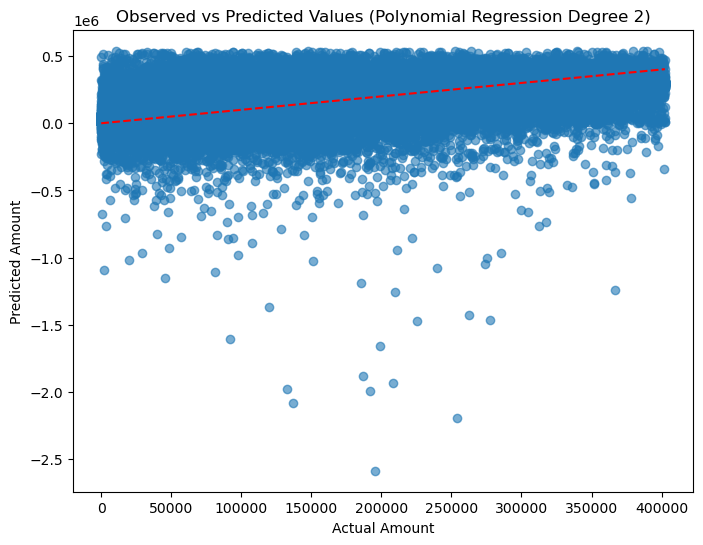

In [53]:
# 14. Visualization
plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_pred, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
plt.xlabel("Actual Amount")
plt.ylabel("Predicted Amount")
plt.title(f"Observed vs Predicted Values ({best_model_name})")
plt.show()